# Description

This notebook cotains a model to predict the daily average load for the next 5 weeks in a single step. The features are detailed in days.

# Load Libs

In [137]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
import pendulum

# custom functions
from Functions.functions import (
                        split_time,
                        create_target_df)

In [37]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [132]:
def load_data(start=2009, end=2021):
    """load data from ONS"""

    cwd_dir = os.getcwd()
     
    first_year = os.path.join(cwd_dir, f'Data/CARGA_ENERGIA_{start}.csv')

    df_20XX = pd.read_csv(first_year, 
                        sep=';', 
                        parse_dates=['din_instante'])

    for x in range(start+1,end+1):
        df_20XX = pd.concat(objs = (df_20XX,
                                    pd.read_csv(os.path.join(cwd_dir, 
                                                            f'Data/CARGA_ENERGIA_{x}.csv'), 
                            sep=';', 
                            parse_dates=['din_instante'])))
    return df_20XX.reset_index(drop=True)

In [133]:
load_col = 'val_cargaenergiamwmed'
time_col = 'din_instante'
regiao = 'SUDESTE'

batch_size = 32
# number of week to be predicted
predict_weeks = 5
# target days to sum into weeks
target_period = 7*predict_weeks
# number of weeks in the window
n_weeks_ws = 5
# window size in days for each row
window_size = 7*n_weeks_ws
filepath = 'Models/Model_v2.h5'
shuffle_buffer = 20
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load data

In [134]:
df_20XX = load_data(start=2009, end=2021)
df_20XX.tail()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
18988,SE,SUDESTE,2021-12-30,38850.805500
18989,N,NORTE,2021-12-31,5396.575583
18990,NE,NORDESTE,2021-12-31,10835.873958
18991,S,SUL,2021-12-31,10689.669167
18992,SE,SUDESTE,2021-12-31,35249.151750


# Preprocess data

In [135]:
class Preprocessor(BaseEstimator, TransformerMixin):

  def __init__(self, regiao):
    self.regiao = regiao
    self.missing_days = []
    pass


  def fit(self, df:pd.DataFrame):
    """ Learns the missing days """
    df = df.copy()
    # filter by subsystem
    df = self.filter_subsystem(df, regiao = self.regiao)
    # saves missing days in a variable called missing_days 
    self.missing_days = df[pd.isna(df.val_cargaenergiamwmed)].din_instante
    return self 


  def transform(self, df:pd.DataFrame):
    """ Applies transformations """
    df = df.copy()
    df = self.filter_subsystem(df, regiao = self.regiao)  # filter by subsystem
    df = self.impute_nan(df)                              # impute/drop NaN values
    df = self.go_to_friday(df)        # starts the dataset at a friday - the operative week 
    df = self.parse_dates(df)         # create columns parsing the data
    df = self.drop_incomplete_week(df)    # drop last rows so to have full weeks
    self.check_dq(df)                   # prints the NaN values for loadand missing days
    return df


  def go_to_friday(self,df): 
    """ go next friday = begining of the operative week"""
    df = df.copy()
    # first day in dataset
    date_time = df['din_instante'].iloc[0]
    # check if the dataset starts on a friday 
    if date_time.day_name() != 'Friday':
      # today
      dt = pendulum.datetime(date_time.year,date_time.month, date_time.day)
      # next friday - begins the operative week
      next_friday = dt.next(pendulum.FRIDAY).strftime('%Y-%m-%d')
      # df starts with the begin of operative week
      df = df[df['din_instante'] >= next_friday].reset_index(drop=True).copy()
    
    return df


  def filter_subsystem(self, df:pd.DataFrame, regiao:str):
    """ filter data by subsystem and reset index """
    df = df.copy()
    # try and execept so it doesn't crash if it's applied to an already treated dataset
    try:
      df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
    except:
      pass
    # dropa columns about subsystem
    df.drop(labels=['nom_subsistema','id_subsistema'], inplace=True, axis=1,errors='ignore')
    # reset index of concatenated datasets
    df.reset_index(inplace=True,drop=True)
    return df


  def parse_dates(self, df):
    """ parse date into year, month, month day and week day  """
    df = df.copy()
    
    df['semana'] = (df.index)//7
    df['dia semana'] = df['din_instante'].dt.day_name()
    df['dia mes'] = df['din_instante'].dt.day
    df['Mes'] = df['din_instante'].dt.month
    df['ano'] = df['din_instante'].dt.year
    return df


  def drop_incomplete_week(self,df):
    """ drop incomplete week at the bottom of the dataset """
    for i in range(6):
      if df['dia semana'].tail(1).item() == 'Thursday':
        break
      else:
        df.drop(labels=df.tail(1).index, axis=0, inplace=True)

    return df
  

  def impute_nan(self, df):
    """ impute the 12 NaN values """
    df = df.copy()
    time_col = 'din_instante'
    load_col = 'val_cargaenergiamwmed'
    if len(self.missing_days) != 0:
      # If the NaN weren't already dealt with:
      if df[df[time_col] == self.missing_days.iloc[0]].val_cargaenergiamwmed.isna().item():
        # impute missing day '2013-12-01' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[0]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[0] - 1]
        # impute missing day '2014-02-01' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[1]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[1] - 1]
        # impute missing day '2015-04-09' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[2]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[2] - 1]
        # drop days from incomplete week in 2016 - from '2016-04-01' to '2016-04-14'
        df[time_col] = pd.to_datetime(df[time_col])
        df = df.drop(axis=0, index = df[(df[time_col] >= '2016-04-01') & (df[time_col] <= '2016-04-14')].index)
    
    return df
  

  def check_dq(self,df):
    # check for NaN values
    nan_data = df[pd.isna(df.val_cargaenergiamwmed)].din_instante
    if len(nan_data) != 0:
        print("NaN values: \n")
        print(nan_data)
    else:
        print('No missing NaN.')
    
    # check for missing days in the series
    missing_days = pd.date_range(start = df.din_instante.iloc[0], 
                                 end= df.din_instante.iloc[-1],
                                 freq='D').difference(df.din_instante)
    if len(missing_days) != 0:
        print("\nMissing days in the series:")
        print(missing_days)
    else:
        print("\nNo missing days in the series")

In [138]:
pp = Preprocessor(regiao='SUDESTE')
df = pp.fit_transform(df_20XX)
df.tail(8)

No missing NaN.

Missing days in the series:
DatetimeIndex(['2016-04-01', '2016-04-02', '2016-04-03', '2016-04-04',
               '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08',
               '2016-04-09', '2016-04-10', '2016-04-11', '2016-04-12',
               '2016-04-13', '2016-04-14'],
              dtype='datetime64[ns]', freq=None)


,din_instante,val_cargaenergiamwmed,semana,dia semana,dia mes,Mes,ano
4724,2021-12-23,40538.381833,674,Thursday,23,12,2021
4725,2021-12-24,35745.640917,675,Friday,24,12,2021
4726,2021-12-25,31276.821042,675,Saturday,25,12,2021
4727,2021-12-26,33942.445250,675,Sunday,26,12,2021
4728,2021-12-27,39736.502167,675,Monday,27,12,2021
4729,2021-12-28,40201.573667,675,Tuesday,28,12,2021
4730,2021-12-29,40083.157792,675,Wednesday,29,12,2021
4731,2021-12-30,38850.805500,675,Thursday,30,12,2021


# Split Data

In [140]:
# index of end of training dataset, start of validation dataset
split_val = int(len(df)*0.7)
# index of end of validation dataset, start of test dataset
split_test = int(len(df)*0.9)
# date when starts the validation and test sets 
date_val = df.iloc[split_val][time_col]
date_test = df.iloc[split_test][time_col]
# window_size date interval
delta_window = pd.to_timedelta(window_size,unit='d')
# split validation data date + window_size
d2 = date_val + delta_window
# split test data date + window_size
d3 = date_test + delta_window 

In [141]:
train_df, val_df, test_df = split_time(split_val = split_val, 
                                       split_test = split_test,
                                       df=df_20XX,
                                       regiao=regiao)

No missing NaN.

Missing days in the series:
DatetimeIndex(['2016-04-01', '2016-04-02', '2016-04-03', '2016-04-04',
               '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08',
               '2016-04-09', '2016-04-10', '2016-04-11', '2016-04-12',
               '2016-04-13', '2016-04-14'],
              dtype='datetime64[ns]', freq=None)
No missing NaN.

Missing days in the series:
DatetimeIndex(['2016-04-01', '2016-04-02', '2016-04-03', '2016-04-04',
               '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08',
               '2016-04-09', '2016-04-10', '2016-04-11', '2016-04-12',
               '2016-04-13', '2016-04-14'],
              dtype='datetime64[ns]', freq=None)
No missing NaN.

No missing days in the series
No missing NaN.

No missing days in the series


# Process Data 

In [145]:
class Window_Generator(BaseEstimator):
    
    def __init__(self,target_period, window_size, batch_size,
                 shuffle_buffer, regiao = regiao, SEED=SEED):
        self.target_period = target_period
        self.window_size = window_size
        self.batch_size = batch_size
        self.shuffle_buffer = shuffle_buffer
        self.regiao = regiao
        self.SEED = SEED
    pass
    
    def generate_data_week(self, df):
        """Generate a list with the same index as the window features with the first
            day of the first week of the target

        Args:
            df (pd.DataFrame): preprocessed dataframe 

        Returns:
            data_week: first day of the first target week
        """
        df = df.copy()
        if df['din_instante'].iloc[0].day_name() != 'Friday':
            # get next friday - begins the operative week
            df = Preprocessor(regiao=self.regiao).go_to_friday(df)
        # groupby object by week and then by day
        df_grouped = df[self.window_size:].groupby(by=['semana'])['din_instante']
        # get first day of each week
        return df_grouped.min()

    def transform(self, df, shuffle=True):
        """Transform a preprocessed dataframe in a windowed dataset

        Args:
            df (pd.DataFrame): preprocessed dataframe

        Returns:
            dataset: a windowed tensorflow.dataset with window_size timesteps for features
                     and the average daily load for the next five weeks as targets
        """
        df = df.copy()
        data_week = self.generate_data_week(df)

        series = df['val_cargaenergiamwmed']
        # generate tf.dataset
        dataset = tf.data.Dataset.from_tensor_slices(series)
        # create windows 
        dataset = dataset.window(self.window_size + self.target_period, shift=7, drop_remainder=True)
        # make sure every window is the same size / clip NaN at the end
        dataset = dataset.flat_map(lambda window: window.batch(self.window_size + self.target_period))
        if shuffle:
            # randomly shuffles the windows instances in the dataset 
            dataset = dataset.shuffle(self.shuffle_buffer,seed=self.SEED)
        # separates features and target and average the target days
        dataset = dataset.map(lambda window:(window[:-self.target_period],   #features
                                            [tf.math.reduce_sum(window[-35:-28])/7, # first target week
                                            tf.math.reduce_sum(window[-28:-21])/7, # second target week
                                            tf.math.reduce_sum(window[-21:-14])/7, # third target week
                                            tf.math.reduce_sum(window[-14:-7])/7,  # fourth target week
                                            tf.math.reduce_sum(window[-7:])/7]      # fifith target week
                                            )
                            )
        # batch and prefetch
        dataset = dataset.batch(batch_size).prefetch(1)
        
        
        return dataset, data_week

wd = Window_Generator(batch_size = 32, window_size = 7*5, shuffle_buffer = 20, target_period = 35, SEED = SEED)



# dataset to training
train_dataset, train_data_week = wd.transform(df = train_df, shuffle=True)

# dataset for performance evaluation
train_pred_dataset, train_pred_data_week = wd.transform(df = train_df, shuffle=False)
val_dataset, val_data_week = wd.transform(df = val_df, shuffle=False)
test_dataset, test_data_week = wd.transform(df = test_df, shuffle=False)

In [146]:
c=0
for x,y in train_pred_dataset:
  #print('x=', x)
  print('y=', y)
  break
  c +=1
print(c*batch_size)

y= tf.Tensor(
[[32150.67732143 31443.20309524 29987.83952381 33188.86875
  33265.60095238]
 [31443.20309524 29987.83952381 33188.86875    33265.60095238
  32117.11928571]
 [29987.83952381 33188.86875    33265.60095238 32117.11928571
  31351.43904762]
 [33188.86875    33265.60095238 32117.11928571 31351.43904762
  31408.69166667]
 [33265.60095238 32117.11928571 31351.43904762 31408.69166667
  31249.35208333]
 [32117.11928571 31351.43904762 31408.69166667 31249.35208333
  29440.66482143]
 [31351.43904762 31408.69166667 31249.35208333 29440.66482143
  29038.87416667]
 [31408.69166667 31249.35208333 29440.66482143 29038.87416667
  30322.04970238]
 [31249.35208333 29440.66482143 29038.87416667 30322.04970238
  28690.34339286]
 [29440.66482143 29038.87416667 30322.04970238 28690.34339286
  30607.21232143]
 [29038.87416667 30322.04970238 28690.34339286 30607.21232143
  29928.79238095]
 [30322.04970238 28690.34339286 30607.21232143 29928.79238095
  30443.53714286]
 [28690.34339286 30607.212321

# Target

In [147]:
def create_target_df(df):
  """ returns a dataframe with target values and baseline"""
  # average daily load by operative week
  df_target = pd.DataFrame(data=df.groupby(by=['semana'])['val_cargaenergiamwmed'].mean())
  # start day of each operative week
  df_target.columns = ['Semana 1']
  df_target['Semana 2'] = df_target['Semana 1'].shift(-1)
  df_target['Semana 3'] = df_target['Semana 1'].shift(-2)
  df_target['Semana 4'] = df_target['Semana 1'].shift(-3)
  df_target['Semana 5'] = df_target['Semana 1'].shift(-4)
  df_target['Data'] = df.groupby(by=['semana'])[time_col].min()
  df_target['dia semana'] = df.groupby(by=['semana'])['dia semana'].min()
  df_target['baseline'] = df_target['Semana 1'].shift(1)
  return df_target


df_target = create_target_df(df)
df_target.head(6)

,Semana 1,Semana 2,Semana 3,Semana 4,Semana 5,Data,dia semana,baseline
semana,,,,,,,,
0,27536.563810,31029.189762,30444.169583,29957.378095,31392.350119,2009-01-02,Friday,NaN
1,31029.189762,30444.169583,29957.378095,31392.350119,32150.677321,2009-01-09,Friday,27536.563810
2,30444.169583,29957.378095,31392.350119,32150.677321,31443.203095,2009-01-16,Friday,31029.189762
3,29957.378095,31392.350119,32150.677321,31443.203095,29987.839524,2009-01-23,Friday,30444.169583
4,31392.350119,32150.677321,31443.203095,29987.839524,33188.868750,2009-01-30,Friday,29957.378095
5,32150.677321,31443.203095,29987.839524,33188.868750,33265.600952,2009-02-06,Friday,31392.350119


# Baseline

In [53]:
def baseline_metrics(df_target):
    # indexes for .loc for each set of data 
    train_ix_base = ((df_target['Data'] < date_val) & (df_target['Data'] >= '2009-05-22'))
    val_ix_base = ((df_target['Data'] > d2) & (df_target['Data']<date_test))
    test_ix_base = df_target['Data']> d3


    # metrics for baseline model
    metrics_baseline = pd.DataFrame(index = ['train', 'val', 'test'], 
                        data = 

            {'MAE' : [tf.keras.metrics.mean_absolute_error(
            df_target.loc[ix][load_col][1:],
            df_target.loc[ix]['baseline'][1:]).numpy() 
            for ix in [train_ix_base, val_ix_base, test_ix_base]],
            
            'MAPE' : [tf.keras.metrics.mape(
            df_target.loc[ix][load_col][1:],
            df_target.loc[ix]['baseline'][1:]).numpy() 
            for ix in [train_ix_base, val_ix_base, test_ix_base]],
            
            'MSE' : [tf.keras.metrics.mse(
            df_target.loc[ix][load_col][1:],
            df_target.loc[ix]['baseline'][1:]).numpy() 
            for ix in [train_ix_base, val_ix_base, test_ix_base]],

            'MSLE' : [tf.keras.metrics.msle(
            df_target.loc[ix][load_col][1:],
            df_target.loc[ix]['baseline'][1:]).numpy() 
            for ix in [train_ix_base, val_ix_base, test_ix_base]],

            'RMSE' : [tf.keras.metrics.RootMeanSquaredError().update_state(
            df_target.loc[ix][load_col][1:],
            df_target.loc[ix]['baseline'][1:]).numpy() 
            for ix in [train_ix_base, val_ix_base, test_ix_base]]          
            })

    metrics_baseline

KeyError: 'val_cargaenergiamwmed'

# train model

In [148]:
def compile_and_fit(model, data, val_data, epochs,optimizer,
                    filepath=filepath, patience=4):
  # early stopping callback
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')
  # checkpoint callback
  checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath = filepath, monitor = 'loss', 
                               verbose = 1, save_best_only = True, mode = 'min')
  
  # compile
  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=optimizer,
                metrics=[tf.metrics.MeanAbsoluteError(),
                         tf.metrics.MeanAbsolutePercentageError(),
                         tf.keras.metrics.RootMeanSquaredError()])
  # fit data
  history = model.fit(data, epochs=epochs, verbose=0,
                      validation_data= val_data,
                      callbacks=[early_stopping]) #  checkpoint
  return history

In [156]:
weight_decay = 5.29435315233284e-06

optimizer = tf.optimizers.Adam(learning_rate=0.00126053961) #Adagrad(learning_rate= 0.9580, epsilon = 2.645-08)

l0 = tf.keras.layers.LSTM(128, return_sequences=False, 
#                          kernel_regularizer=tf.keras.regularizers.l2(weight_decay),
#                          recurrent_dropout = 0.2,
                          activation ='tanh')
l1 = tf.keras.layers.LSTM(8, return_sequences=False, 
#                          kernel_regularizer=tf.keras.regularizers.l2(weight_decay), 
#                          recurrent_dropout = 0.2,
                          activation ='tanh')

# LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    l0,
    #l1,
    tf.keras.layers.Dense(5), #, kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])


history = compile_and_fit(model, epochs = 50, 
                          data=train_dataset, 
                          val_data = val_dataset,
                          optimizer = optimizer,
                          patience = 50,
                          filepath = filepath)


#print("Layer weights {}".format(l0.get_weights())) 

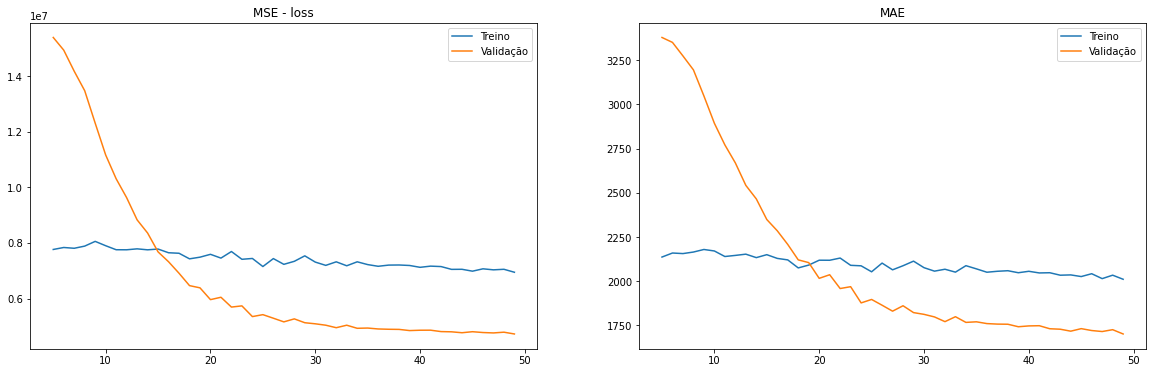

In [157]:
# evaluate training metrics

# starting epoch to plot
skip = 5

fig,ax = plt.subplots(figsize=(20,6), nrows=1, ncols=2)
metrics_list = ['loss',
                'val_loss',
                'mean_absolute_error', 
                'val_mean_absolute_error'
                ]

for i, metric in enumerate(metrics_list):
  if i<=1:
    ax1 =  ax.ravel()[0]
  else:
    ax1 =  ax.ravel()[1]
  sns.lineplot(x = range(skip,len(history.history[metric])),
              y = history.history[metric][skip:],
              ax = ax1)


ax.ravel()[0].set_title("MSE - loss")
ax.ravel()[0].legend(labels=['Treino', 'Validação'])
ax.ravel()[1].set_title("MAE")
ax.ravel()[1].legend(labels=['Treino', 'Validação'])

plt.show()

2/2 [==============================] - 0s 22ms/step - loss: 5782487.0000 - mean_absolute_error: 1859.9122 - mean_absolute_percentage_error: 4.6252 - root_mean_squared_error: 2404.6804


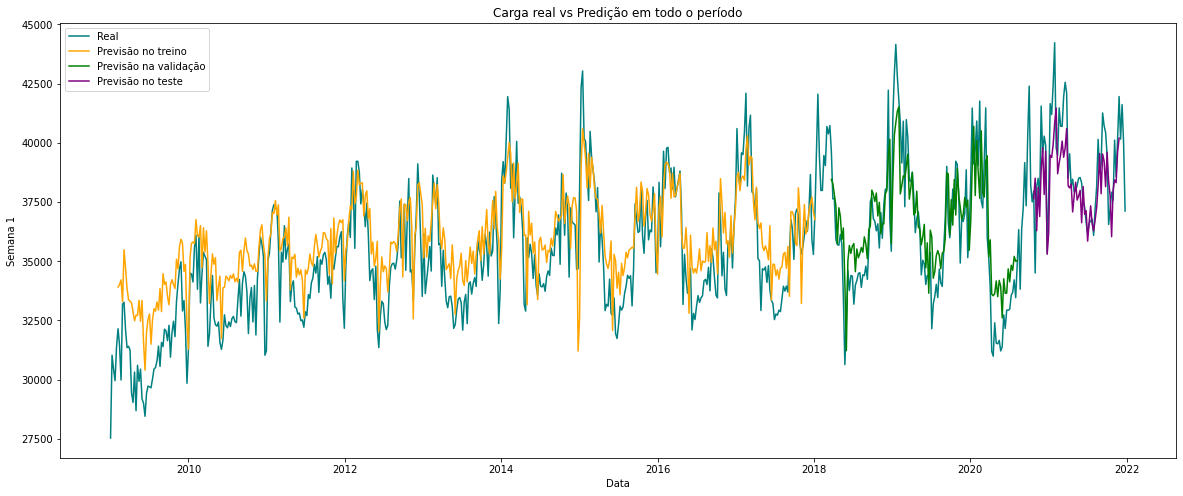

In [158]:
# load weights from the epoch with best validation loss in training
#model.load_weights(filepath)
# make predictions
train_pred = model.predict(train_pred_dataset)[:, 0]
val_pred = model.predict(val_dataset)[:, 0]
test_pred = model.predict(test_dataset)[:, 0]

fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['Data'], 
             y = df_target['Semana 1'], ax=ax, color = 'teal')

# plot predicted data
for date,pred,color in zip([train_pred_data_week,val_data_week,test_data_week], 
                           [train_pred, val_pred, test_pred],
                           ['orange', 'green', 'purple']): 
  sns.lineplot(x = date[:-4],
               y = pred, 
               ax=ax, 
               color=color)
#scores = f"MAE on val : {metrics_df.MAE.iloc[0]}"

plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 
            'Previsão no treino', 
            'Previsão na validação', 
            'Previsão no teste'])

# evaluate performance
train_performance = {}
train_performance['LSTM'] = model.evaluate(train_dataset)
val_performance = {}
val_performance['LSTM'] = model.evaluate(val_dataset)
performance = {}
performance['LSTM'] = model.evaluate(test_dataset,)

2/2 [==============================] - 0s 19ms/step - loss: 4682997.0000 - mean_absolute_error: 1605.9189 - mean_absolute_percentage_error: 4.0319 - root_mean_squared_error: 2164.0234


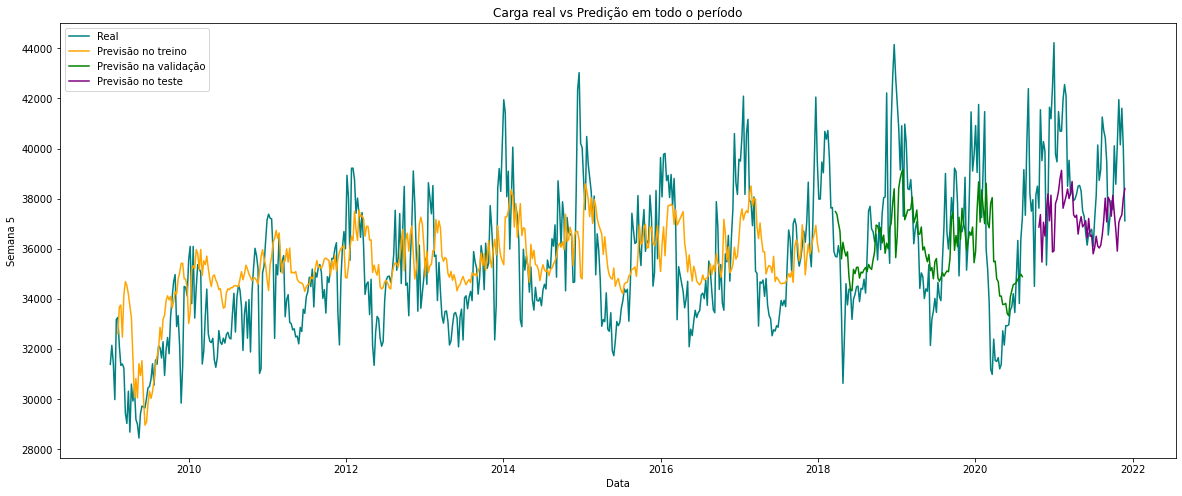

In [159]:
# load weights from the epoch with best validation loss in training
#model.load_weights(filepath)
# make predictions
train_pred = model.predict(train_pred_dataset)
val_pred = model.predict(val_dataset)
test_pred = model.predict(test_dataset)

fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['Data'], 
             y = df_target['Semana 5'], ax=ax, color = 'teal')

# plot predicted data
for date,pred,color in zip([train_pred_data_week,val_data_week,test_data_week], 
                           [train_pred, val_pred, test_pred],
                           ['orange', 'green', 'purple']): 
  sns.lineplot(x = date[:-4],
               y = pred[:, 4], 
               ax=ax, 
               color=color)
#scores = f"MAE on val : {metrics_df.MAE.iloc[0]}"

plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 
            'Previsão no treino', 
            'Previsão na validação', 
            'Previsão no teste'])

# evaluate performance
train_performance = {}
train_performance['LSTM'] = model.evaluate(train_dataset)
val_performance = {}
val_performance['LSTM'] = model.evaluate(val_dataset)
performance = {}
performance['LSTM'] = model.evaluate(test_dataset,)

# Residual Analysis